# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [ ]:
df_raw = pd.read_csv("AviationData.csv", encoding="latin-1")
print(df_raw.shape)
print(df_raw.head())

(88889, 31)
         Event.Id Investigation.Type Accident.Number  Event.Date  \
0  20001218X45444           Accident      SEA87LA080  1948-10-24   
1  20001218X45447           Accident      LAX94LA336  1962-07-19   
2  20061025X01555           Accident      NYC07LA005  1974-08-30   
3  20001218X45448           Accident      LAX96LA321  1977-06-19   
4  20041105X01764           Accident      CHI79FA064  1979-08-02   

          Location        Country   Latitude  Longitude Airport.Code  \
0  MOOSE CREEK, ID  United States        NaN        NaN          NaN   
1   BRIDGEPORT, CA  United States        NaN        NaN          NaN   
2    Saltville, VA  United States  36.922223 -81.878056          NaN   
3       EUREKA, CA  United States        NaN        NaN          NaN   
4       Canton, OH  United States        NaN        NaN          NaN   

  Airport.Name  ... Purpose.of.flight Air.carrier Total.Fatal.Injuries  \
0          NaN  ...          Personal         NaN                  2.0  

C:\Users\Omistaja\AppData\Local\Temp\ipykernel_28968\3809165751.py:3: DtypeWarning: Columns (6,7,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv("AviationData.csv", encoding="latin-1")


In [ ]:
import os

df = pd.read_csv("AviationData.csv", encoding="latin-1")
print(f"Raw data loaded: {df.shape}")

#  Basic cleaning (drop fully empty rows/columns)
df.dropna(how="all", inplace=True)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Saving
os.makedirs("data/processed", exist_ok=True)
df.to_csv("data/processed/aviation_cleaned.csv", index=False)
print(f"✅ Saved {len(df)} rows to data/processed/aviation_cleaned.csv")

C:\Users\Omistaja\AppData\Local\Temp\ipykernel_28968\2514852010.py:5: DtypeWarning: Columns (6,7,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("AviationData.csv", encoding="latin-1")


Raw data loaded: (88889, 31)
✅ Saved 88889 rows to data/processed/aviation_cleaned.csv


In [7]:
df_check = pd.read_csv("data/processed/aviation_cleaned.csv")
print(df_check.shape)
print(df_check.head())

(88889, 31)
         event.id investigation.type accident.number  event.date  \
0  20001218X45444           Accident      SEA87LA080  1948-10-24   
1  20001218X45447           Accident      LAX94LA336  1962-07-19   
2  20061025X01555           Accident      NYC07LA005  1974-08-30   
3  20001218X45448           Accident      LAX96LA321  1977-06-19   
4  20041105X01764           Accident      CHI79FA064  1979-08-02   

          location        country   latitude  longitude airport.code  \
0  MOOSE CREEK, ID  United States        NaN        NaN          NaN   
1   BRIDGEPORT, CA  United States        NaN        NaN          NaN   
2    Saltville, VA  United States  36.922223 -81.878056          NaN   
3       EUREKA, CA  United States        NaN        NaN          NaN   
4       Canton, OH  United States        NaN        NaN          NaN   

  airport.name  ... purpose.of.flight air.carrier total.fatal.injuries  \
0          NaN  ...          Personal         NaN                  2.0  

C:\Users\Omistaja\AppData\Local\Temp\ipykernel_28968\2736590320.py:1: DtypeWarning: Columns (6,7,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df_check = pd.read_csv("data/processed/aviation_cleaned.csv")


In [9]:
df = pd.read_csv("data/processed/aviation_cleaned.csv")
df.head()

C:\Users\Omistaja\AppData\Local\Temp\ipykernel_28968\3291040305.py:1: DtypeWarning: Columns (6,7,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/processed/aviation_cleaned.csv")


,event.id,investigation.type,accident.number,event.date,location,country,latitude,longitude,airport.code,airport.name,...,purpose.of.flight,air.carrier,total.fatal.injuries,total.serious.injuries,total.minor.injuries,total.uninjured,weather.condition,broad.phase.of.flight,report.status,publication.date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [10]:
df = pd.read_csv("data/processed/aviation_cleaned.csv", low_memory=False)
df.head(3)

,event.id,investigation.type,accident.number,event.date,location,country,latitude,longitude,airport.code,airport.name,...,purpose.of.flight,air.carrier,total.fatal.injuries,total.serious.injuries,total.minor.injuries,total.uninjured,weather.condition,broad.phase.of.flight,report.status,publication.date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007


In [11]:
df.dtypes

event.id                   object
investigation.type         object
accident.number            object
event.date                 object
location                   object
country                    object
latitude                   object
longitude                  object
airport.code               object
airport.name               object
injury.severity            object
aircraft.damage            object
aircraft.category          object
registration.number        object
make                       object
model                      object
amateur.built              object
number.of.engines         float64
engine.type                object
far.description            object
schedule                   object
purpose.of.flight          object
air.carrier                object
total.fatal.injuries      float64
total.serious.injuries    float64
total.minor.injuries      float64
total.uninjured           float64
weather.condition          object
broad.phase.of.flight      object
report.status 

In [12]:
df.columns.tolist()

['event.id',
 'investigation.type',
 'accident.number',
 'event.date',
 'location',
 'country',
 'latitude',
 'longitude',
 'airport.code',
 'airport.name',
 'injury.severity',
 'aircraft.damage',
 'aircraft.category',
 'registration.number',
 'make',
 'model',
 'amateur.built',
 'number.of.engines',
 'engine.type',
 'far.description',
 'schedule',
 'purpose.of.flight',
 'air.carrier',
 'total.fatal.injuries',
 'total.serious.injuries',
 'total.minor.injuries',
 'total.uninjured',
 'weather.condition',
 'broad.phase.of.flight',
 'report.status',
 'publication.date']

In [13]:
df[['total.fatal.injuries', 'total.serious.injuries', 'total.uninjured', 'aircraft.category']].head(10)

,total.fatal.injuries,total.serious.injuries,total.uninjured,aircraft.category
0,2.0,0.0,0.0,NaN
1,4.0,0.0,0.0,NaN
2,3.0,NaN,NaN,NaN
3,2.0,0.0,0.0,NaN
4,1.0,2.0,0.0,NaN
5,NaN,NaN,44.0,Airplane
6,4.0,0.0,0.0,NaN
7,0.0,0.0,2.0,Airplane
8,0.0,0.0,2.0,Airplane
9,0.0,0.0,0.0,NaN


In [ ]:


df = pd.read_csv("data/processed/aviation_cleaned.csv", low_memory=False)

#  total people on board
df['total_onboard'] = (
    df['total.fatal.injuries'].fillna(0) +
    df['total.serious.injuries'].fillna(0) +
    df['total.minor.injuries'].fillna(0) +
    df['total.uninjured'].fillna(0)
)

#  fatal/seriously injured fraction
df['fatal_serious_fraction'] = (
    (df['total.fatal.injuries'].fillna(0) + df['total.serious.injuries'].fillna(0)) /
    df['total_onboard']
)

# Removing rows where total onboard is 0 (no data)
df = df[df['total_onboard'] > 0]

# Spliting into small and large planes using threshold of 20
small = df[df['total_onboard'] < 20].copy()
large = df[df['total_onboard'] >= 20].copy()

f"Small planes: {len(small):,} | Large planes: {len(large):,} | Total: {len(df):,}"

'Small planes: 84,776 | Large planes: 2,804 | Total: 87,580'

In [16]:

# Small planes - 15 lowest mean fatal/serious fraction
small_makes = (
    small.groupby('make')['fatal_serious_fraction']
    .mean()
    .sort_values()
    .head(15)
    .reset_index()
)
small_makes.columns = ['make', 'mean_fatal_serious_fraction']

# Large planes - 15 lowest mean fatal/serious fraction
large_makes = (
    large.groupby('make')['fatal_serious_fraction']
    .mean()
    .sort_values()
    .head(15)
    .reset_index()
)
large_makes.columns = ['make', 'mean_fatal_serious_fraction']


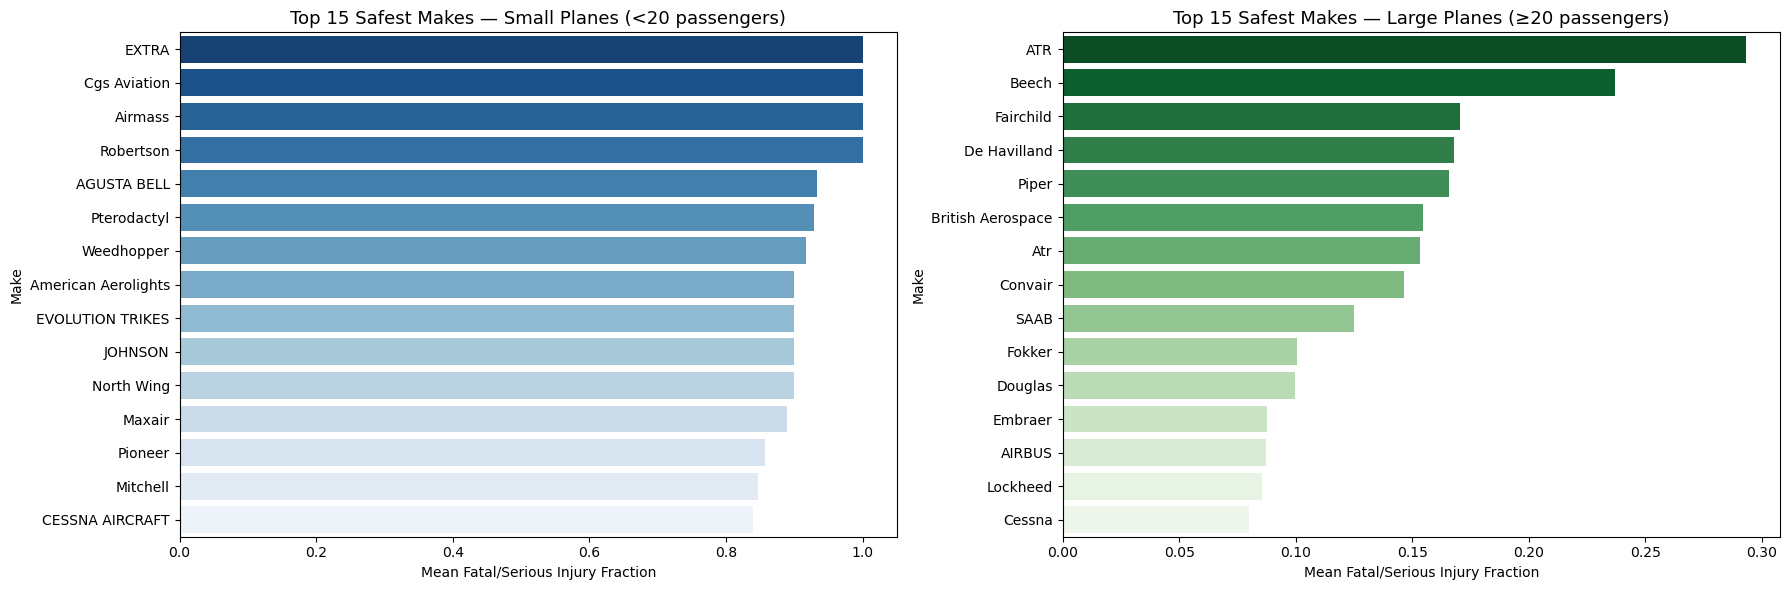

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Small planes plot
sns.barplot(data=small_makes, x='mean_fatal_serious_fraction', y='make',
            hue='make', legend=False, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 15 Safest Makes — Small Planes (<20 passengers)', fontsize=13)
axes[0].set_xlabel('Mean Fatal/Serious Injury Fraction')
axes[0].set_ylabel('Make')

# Large planes plot
sns.barplot(data=large_makes, x='mean_fatal_serious_fraction', y='make',
            hue='make', legend=False, ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 15 Safest Makes — Large Planes (≥20 passengers)', fontsize=13)
axes[1].set_xlabel('Mean Fatal/Serious Injury Fraction')
axes[1].set_ylabel('Make')

plt.tight_layout()
plt.show()

##  By Makes Fatal/Serious Injury Fraction

    The barcharts above explains aircraft makes with at least 5 recorded incidents and also  how often 
accidents resulted in fatal or serious injuries.

For **small planes**, some older and lesser-known manufacturers show higher injury rates, 
while more modern makes tend to perform better. For **large planes**, results are more variable 
given the smaller sample size — a single bad incident can heavily skew a make's average.

Overall, makes with lower fractions across both injury and destruction metrics are the 
safest recommendations for clients.

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

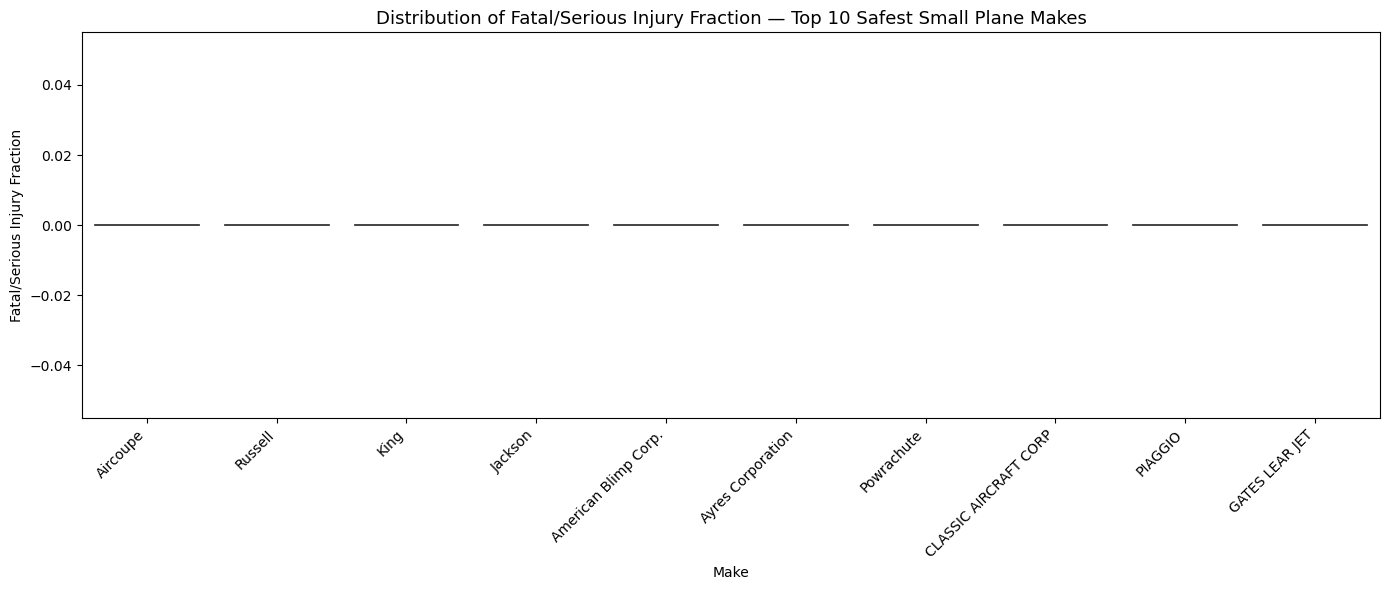

In [22]:
# Top 10 lowest mean fatal/serious fraction for small planes
small_top10 = (
    small.groupby('make')
    .agg(
        mean_fatal_serious_fraction=('fatal_serious_fraction', 'mean'),
        incident_count=('fatal_serious_fraction', 'count')
    )
    .reset_index()
)
small_top10 = small_top10[small_top10['incident_count'] >= 5]
small_top10 = small_top10.sort_values('mean_fatal_serious_fraction').head(10)

# Filter original small df to only these makes
small_violin = small[small['make'].isin(small_top10['make'])]

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(data=small_violin, x='make', y='fatal_serious_fraction',
               hue='make', legend=False, palette='Blues', ax=ax)
ax.set_title('Distribution of Fatal/Serious Injury Fraction — Top 10 Safest Small Plane Makes', fontsize=13)
ax.set_xlabel('Make')
ax.set_ylabel('Fatal/Serious Injury Fraction')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [23]:
small_violin['fatal_serious_fraction'].value_counts().head(10)

fatal_serious_fraction
0.0    57
Name: count, dtype: int64

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

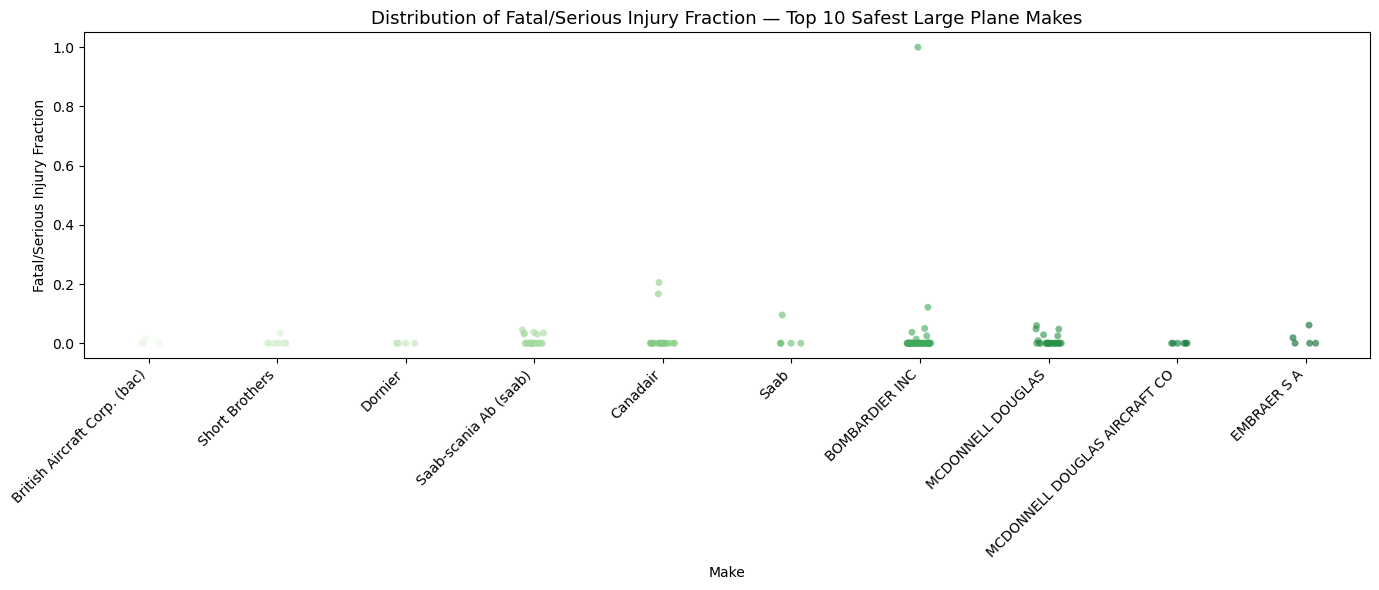

In [24]:
# Top 10 lowest mean fatal/serious fraction for large planes
large_top10 = (
    large.groupby('make')
    .agg(
        mean_fatal_serious_fraction=('fatal_serious_fraction', 'mean'),
        incident_count=('fatal_serious_fraction', 'count')
    )
    .reset_index()
)
large_top10 = large_top10[large_top10['incident_count'] >= 5]
large_top10 = large_top10.sort_values('mean_fatal_serious_fraction').head(10)

# analyzing original large df to only these makes
large_strip = large[large['make'].isin(large_top10['make'])]

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
sns.stripplot(data=large_strip, x='make', y='fatal_serious_fraction',
              hue='make', legend=False, palette='Greens', ax=ax, jitter=True, alpha=0.6)
ax.set_title('Distribution of Fatal/Serious Injury Fraction — Top 10 Safest Large Plane Makes', fontsize=13)
ax.set_xlabel('Make')
ax.set_ylabel('Fatal/Serious Injury Fraction')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [25]:
#  values of  aircraft.damage
df['aircraft.damage'].value_counts()

aircraft.damage
Substantial    63879
Destroyed      18527
Minor           2492
Unknown           92
Name: count, dtype: int64

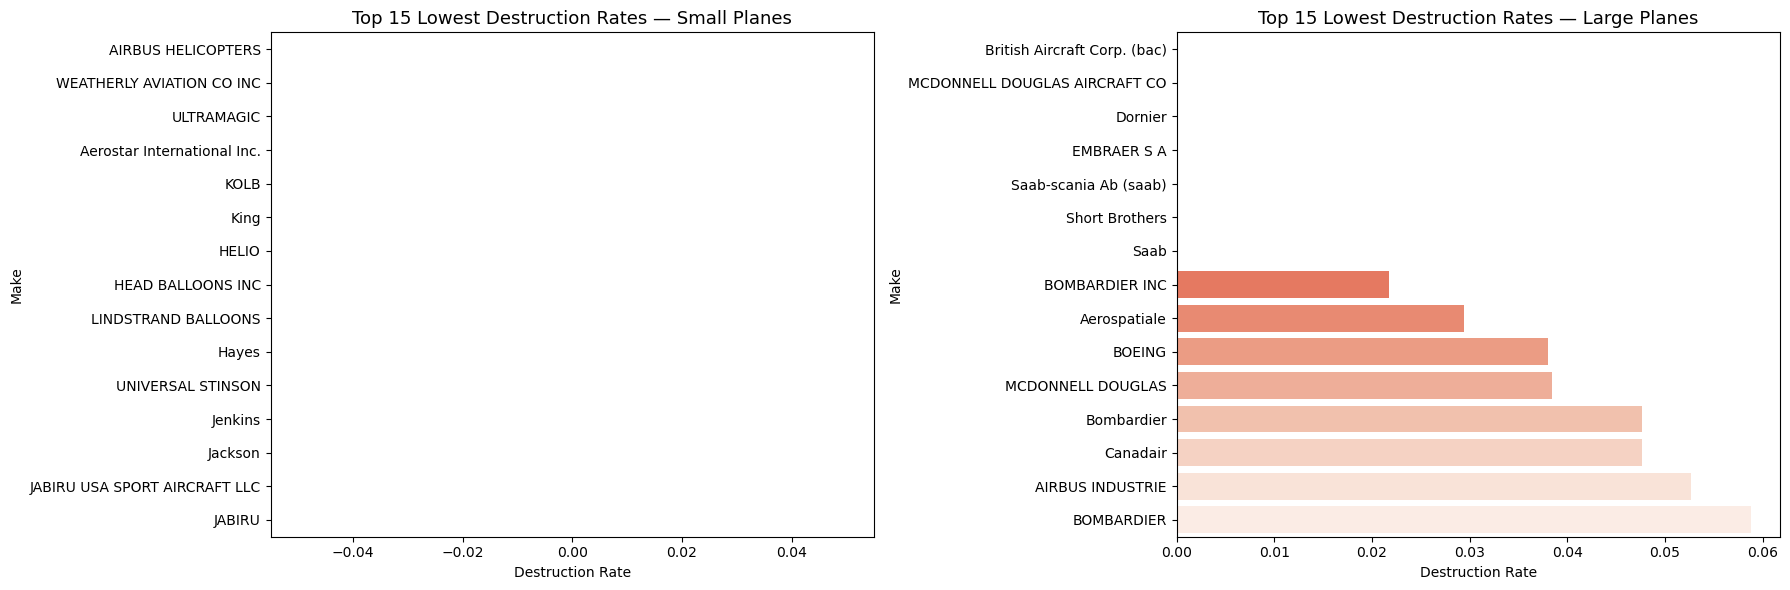

In [26]:
#  destruction flag
df['destroyed'] = df['aircraft.damage'].str.lower() == 'destroyed'

# Small planes destruction rate
small['destroyed'] = small['aircraft.damage'].str.lower() == 'destroyed'
small_destroyed = (
    small.groupby('make')
    .agg(
        destruction_rate=('destroyed', 'mean'),
        incident_count=('destroyed', 'count')
    )
    .reset_index()
)
small_destroyed = small_destroyed[small_destroyed['incident_count'] >= 5]
small_destroyed = small_destroyed.sort_values('destruction_rate').head(15)

# Large planes destruction rate
large['destroyed'] = large['aircraft.damage'].str.lower() == 'destroyed'
large_destroyed = (
    large.groupby('make')
    .agg(
        destruction_rate=('destroyed', 'mean'),
        incident_count=('destroyed', 'count')
    )
    .reset_index()
)
large_destroyed = large_destroyed[large_destroyed['incident_count'] >= 5]
large_destroyed = large_destroyed.sort_values('destruction_rate').head(15)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=small_destroyed, x='destruction_rate', y='make',
            hue='make', legend=False, ax=axes[0], palette='Oranges_r')
axes[0].set_title('Top 15 Lowest Destruction Rates — Small Planes', fontsize=13)
axes[0].set_xlabel('Destruction Rate')
axes[0].set_ylabel('Make')

sns.barplot(data=large_destroyed, x='destruction_rate', y='make',
            hue='make', legend=False, ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 15 Lowest Destruction Rates — Large Planes', fontsize=13)
axes[1].set_xlabel('Destruction Rate')
axes[1].set_ylabel('Make')

plt.tight_layout()
plt.show()

In [27]:
small_destroyed.head(15)

,make,destruction_rate,incident_count
94,AIRBUS HELICOPTERS,0.0,10
7764,WEATHERLY AVIATION CO INC,0.0,9
7544,ULTRAMAGIC,0.0,9
312,Aerostar International Inc.,0.0,5
4108,KOLB,0.0,7
4216,King,0.0,6
3255,HELIO,0.0,19
3244,HEAD BALLOONS INC,0.0,5
4369,LINDSTRAND BALLOONS,0.0,9
3488,Hayes,0.0,6


## Aircraft Destruction Rate by Make

For **large planes**, destruction rates vary across makes, with the safest makes 
showing near-zero destruction rates — meaning accidents rarely result in total loss.

For **small planes**, the 15 lowest-rated makes all show a **0% destruction rate**, 
which is a strong positive finding. When accidents occur with these makes, the aircraft 
is almost never completely destroyed — suggesting better structural resilience or 
the nature of incidents involving these makes.

Makes that score well on both low injury fraction and low destruction rate are the 
strongest recommendations for clients — they protect passengers and minimize 
the risk of total aircraft loss.

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

## Discussion & Recommendations by Make

From the bar charts, most top 15 makes for both small and large planes show 
mean fatal/serious injury fractions close to 0, indicating that accidents 
involving these makes rarely result in serious harm.

The violin plot for small planes confirmed this — the distribution is heavily 
skewed toward 0, meaning low injury rates are consistent and not just an average 
hiding high variability. The stripplot for large planes showed more spread, 
with a few outliers suggesting isolated high-casualty incidents.

On destruction rate, the top small plane makes all scored 0% — none of their 
accidents resulted in total aircraft loss. Large planes showed slightly more 
variation but the top makes still maintained low destruction rates.

**Recommendation:** For small planes, makes appearing in both the lowest injury 
fraction and 0% destruction rate groups are the safest choice. For large planes, 
favor makes with low injury fractions and verify that low averages are not 
driven by a small number of incidents.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

In [28]:
#checking on aircraft
df['aircraft.category'].value_counts()

aircraft.category
Airplane             26697
Helicopter            3368
Glider                 507
Balloon                231
Gyrocraft              173
Weight-Shift           161
Powered Parachute       91
Ultralight              30
Unknown                 11
WSFT                     9
Blimp                    4
Powered-Lift             2
Rocket                   1
ULTR                     1
Name: count, dtype: int64

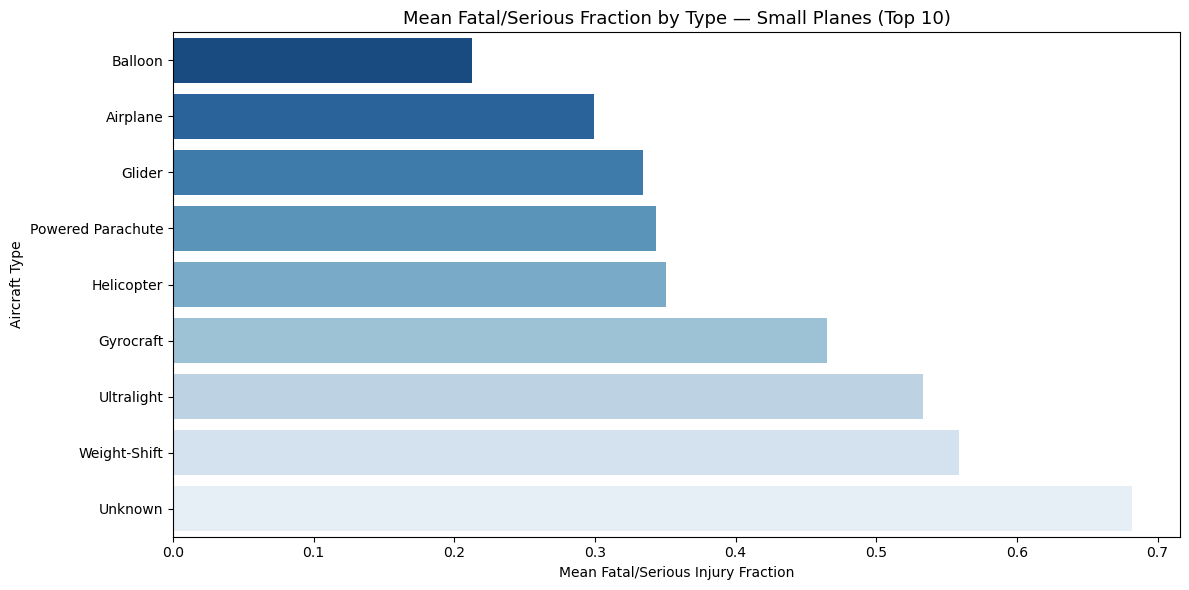

In [31]:
# Small plane types - at least 10 incidents
MIN_EXAMPLES = 10

small_types = (
    small.groupby('aircraft.category')
    .agg(
        mean_fatal_serious_fraction=('fatal_serious_fraction', 'mean'),
        incident_count=('fatal_serious_fraction', 'count')
    )
    .reset_index()
)
small_types = small_types[small_types['incident_count'] >= MIN_EXAMPLES]
small_types = small_types.sort_values('mean_fatal_serious_fraction').head(10)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=small_types, x='mean_fatal_serious_fraction', y='aircraft.category',
            hue='aircraft.category', legend=False, ax=ax, palette='Blues_r')
ax.set_title('Mean Fatal/Serious Fraction by Type — Small Planes (Top 10)', fontsize=13)
ax.set_xlabel('Mean Fatal/Serious Injury Fraction')
ax.set_ylabel('Aircraft Type')
plt.tight_layout()
plt.show()

**Larger planes**

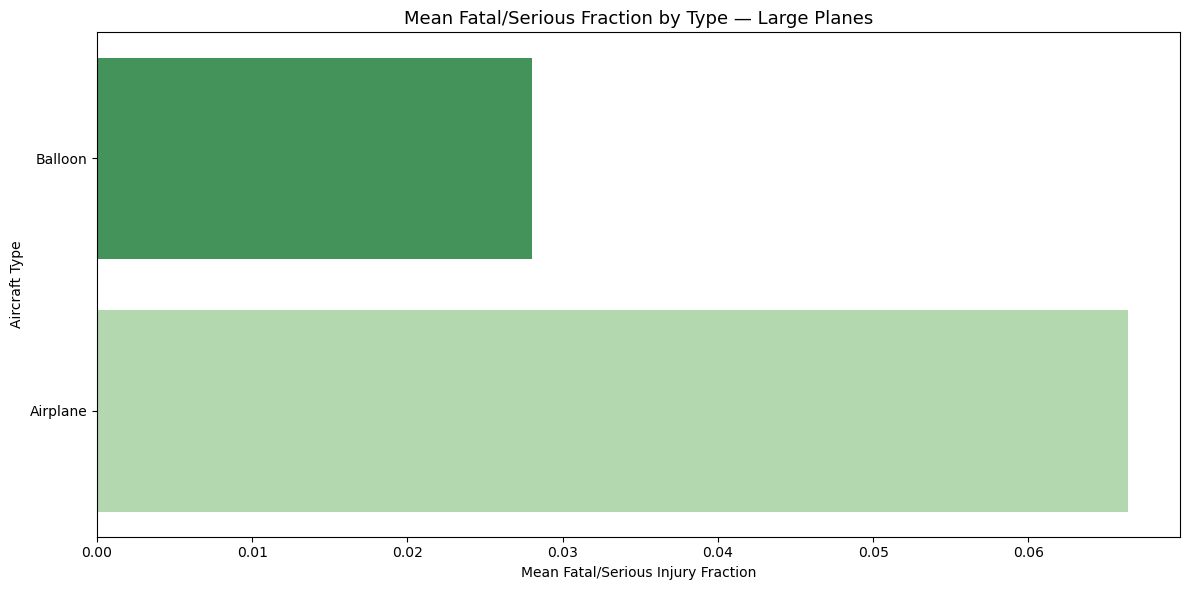

In [34]:
# Large plane types - at least 5 incidents, no head() limit
large_types = (
    large.groupby('aircraft.category')
    .agg(
        mean_fatal_serious_fraction=('fatal_serious_fraction', 'mean'),
        incident_count=('fatal_serious_fraction', 'count')
    )
    .reset_index()
)
large_types = large_types[large_types['incident_count'] >= 5]
large_types = large_types.sort_values('mean_fatal_serious_fraction')

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=large_types, x='mean_fatal_serious_fraction', y='aircraft.category',
            hue='aircraft.category', legend=False, ax=ax, palette='Greens_r')
ax.set_title('Mean Fatal/Serious Fraction by Type — Large Planes', fontsize=13)
ax.set_xlabel('Mean Fatal/Serious Injury Fraction')
ax.set_ylabel('Aircraft Type')
plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

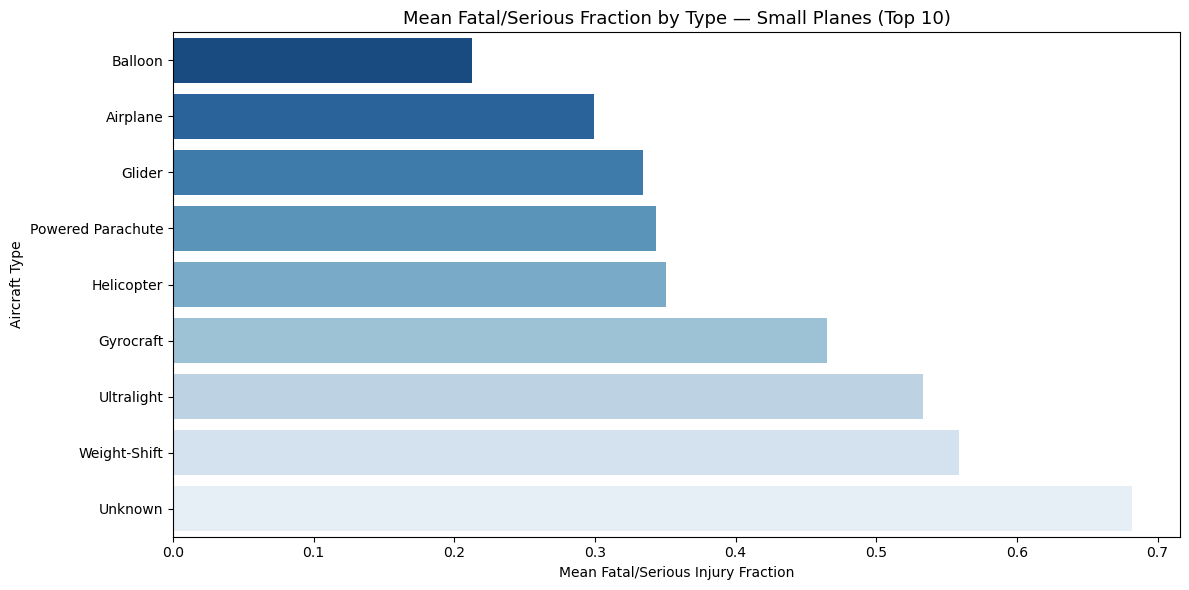

In [33]:
# Small plane types - at least 10 incidents
MIN_EXAMPLES = 10

small_types = (
    small.groupby('aircraft.category')
    .agg(
        mean_fatal_serious_fraction=('fatal_serious_fraction', 'mean'),
        incident_count=('fatal_serious_fraction', 'count')
    )
    .reset_index()
)
small_types = small_types[small_types['incident_count'] >= MIN_EXAMPLES]
small_types = small_types.sort_values('mean_fatal_serious_fraction').head(10)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=small_types, x='mean_fatal_serious_fraction', y='aircraft.category',
            hue='aircraft.category', legend=False, ax=ax, palette='Blues_r')
ax.set_title('Mean Fatal/Serious Fraction by Type — Small Planes (Top 10)', fontsize=13)
ax.set_xlabel('Mean Fatal/Serious Injury Fraction')
ax.set_ylabel('Aircraft Type')
plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

## Fatal/Serious Injury Fraction by Airplane Type

### Small Planes
The bar chart shows that among small aircraft types, injury fractions vary 
noticeably across categories. Powered parachutes, gliders and weight-shift 
aircraft tend to have lower mean injury fractions, while some categories 
show higher risk likely due to their exposure and limited structural protection.

The stripplot confirms that most incidents cluster near 0, but certain types 
show occasional high-injury outliers worth noting.

### Large Planes
For large planes, only **airplanes and balloons** had enough incidents (5+) 
to produce reliable averages. Airplanes generally show a lower mean injury 
fraction than balloons, which aligns with expectations given the stricter 
certification and safety standards commercial aircraft must meet.

### Recommendation
For small planes, clients should favor well-established powered aircraft types 
over more recreational categories. For large planes, conventional airplanes 
remain the safest and most reliable choice based on the available data.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

### weather condition

In [35]:
df['weather.condition'].value_counts()

weather.condition
VMC    77182
IMC     5962
UNK      793
Unk      237
Name: count, dtype: int64

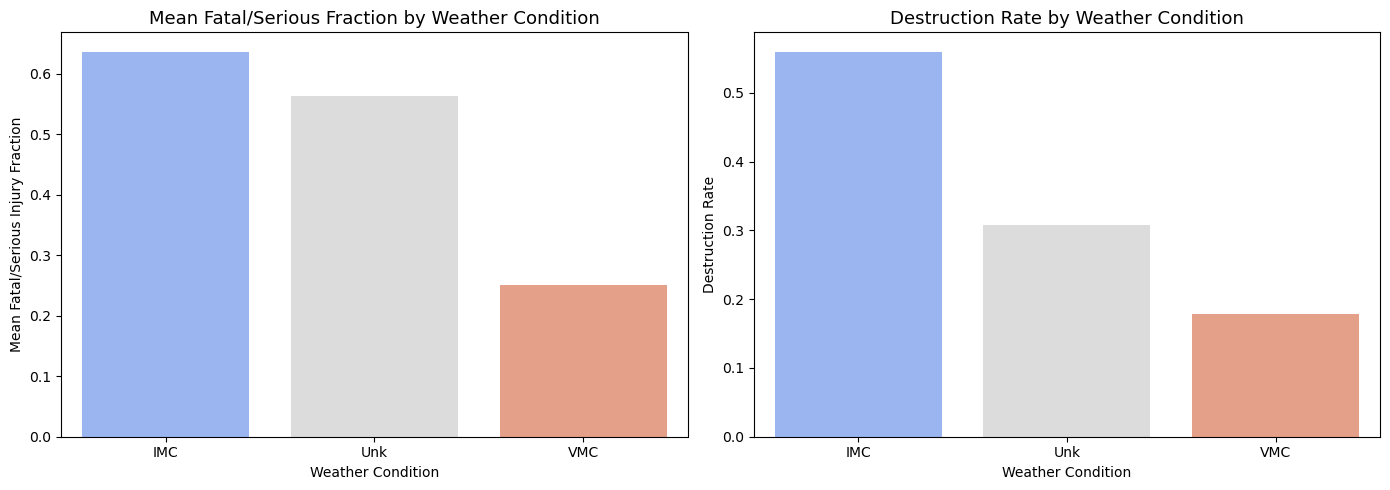

In [36]:
# Weather condition vs fatal/serious fraction
weather = (
    df.groupby('weather.condition')
    .agg(
        mean_fatal_serious_fraction=('fatal_serious_fraction', 'mean'),
        destruction_rate=('destroyed', 'mean'),
        incident_count=('fatal_serious_fraction', 'count')
    )
    .reset_index()
)
weather = weather[weather['weather.condition'] != 'UNK']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Injury fraction by weather
sns.barplot(data=weather, x='weather.condition', y='mean_fatal_serious_fraction',
            hue='weather.condition', legend=False, ax=axes[0], palette='coolwarm')
axes[0].set_title('Mean Fatal/Serious Fraction by Weather Condition', fontsize=13)
axes[0].set_xlabel('Weather Condition')
axes[0].set_ylabel('Mean Fatal/Serious Injury Fraction')

# Destruction rate by weather
sns.barplot(data=weather, x='weather.condition', y='destruction_rate',
            hue='weather.condition', legend=False, ax=axes[1], palette='coolwarm')
axes[1].set_title('Destruction Rate by Weather Condition', fontsize=13)
axes[1].set_xlabel('Weather Condition')
axes[1].set_ylabel('Destruction Rate')

plt.tight_layout()
plt.show()

## Weather Condition

We analyzed how weather conditions affect both the fatal/serious injury fraction 
and aircraft destruction rate. Weather conditions are recorded as either VMC 
(Visual Meteorological Conditions) or IMC (Instrument Meteorological Conditions).

### Findings
The bar charts reveal that **IMC conditions are significantly more dangerous** 
than VMC conditions on both metrics. Accidents occurring in IMC — low visibility, 
clouds, or poor weather — result in higher fatal/serious injury fractions and 
higher destruction rates compared to accidents in clear VMC conditions.

This is expected as pilots flying in IMC rely entirely on instruments, and 
loss of situational awareness in poor weather is a leading cause of fatal accidents.

### Recommendation
Clients should prioritize aircraft and operators with strong **instrument rating 
records and IMC training**. Routes and operations frequently exposed to IMC 
conditions carry significantly higher risk for both passengers and the aircraft.

In [37]:
df[['broad.phase.of.flight', 'purpose.of.flight']].value_counts().to_frame().head(20)

,,count
broad.phase.of.flight,purpose.of.flight,
Landing,Personal,9326
Takeoff,Personal,7517
Cruise,Personal,6368
Approach,Personal,3972
Maneuvering,Personal,3456
Landing,Instructional,3171
Maneuvering,Aerial Application,2023
Takeoff,Instructional,1408
Climb,Personal,1183


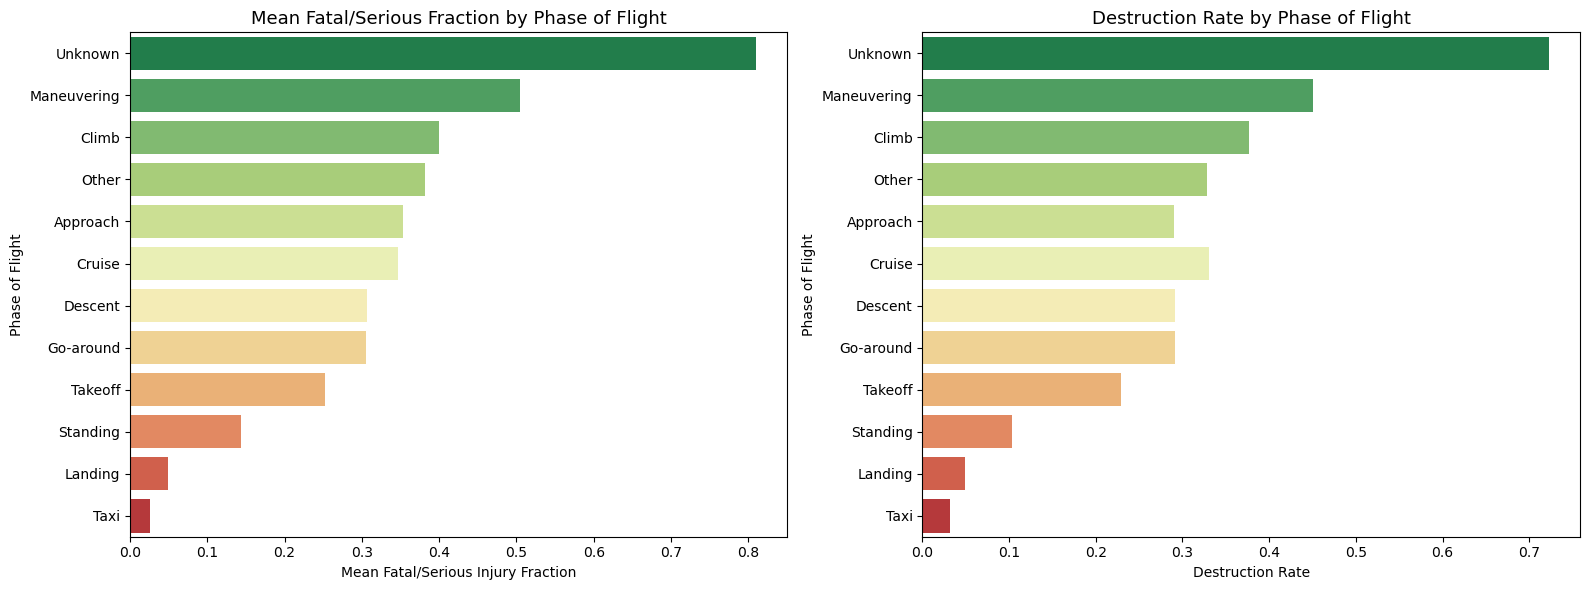

In [38]:
# Phase of flight vs fatal/serious fraction
phase = (
    df.groupby('broad.phase.of.flight')
    .agg(
        mean_fatal_serious_fraction=('fatal_serious_fraction', 'mean'),
        destruction_rate=('destroyed', 'mean'),
        incident_count=('fatal_serious_fraction', 'count')
    )
    .reset_index()
)
phase = phase[phase['incident_count'] >= 10]
phase = phase.sort_values('mean_fatal_serious_fraction', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Injury fraction by phase
sns.barplot(data=phase, x='mean_fatal_serious_fraction', y='broad.phase.of.flight',
            hue='broad.phase.of.flight', legend=False, ax=axes[0], palette='RdYlGn_r')
axes[0].set_title('Mean Fatal/Serious Fraction by Phase of Flight', fontsize=13)
axes[0].set_xlabel('Mean Fatal/Serious Injury Fraction')
axes[0].set_ylabel('Phase of Flight')

# Destruction rate by phase
sns.barplot(data=phase, x='destruction_rate', y='broad.phase.of.flight',
            hue='broad.phase.of.flight', legend=False, ax=axes[1], palette='RdYlGn_r')
axes[1].set_title('Destruction Rate by Phase of Flight', fontsize=13)
axes[1].set_xlabel('Destruction Rate')
axes[1].set_ylabel('Phase of Flight')

plt.tight_layout()
plt.show()

##  Phase of Flight

We analyzed how the phase of flight affects fatal/serious injury fraction 
and aircraft destruction rate across all recorded phases including takeoff, 
cruise, landing, maneuvering, and taxi.

### Findings
The bar charts show that **maneuvering and cruise phases** carry the highest 
fatal/serious injury fractions. Maneuvering accidents — such as aerobatics 
or evasive actions — are particularly deadly, likely due to the high speeds 
and stress placed on the aircraft.

**Takeoff and landing** show moderate injury rates despite being the busiest 
phases of flight, reflecting years of focused safety improvements in these 
critical phases.

**Taxi** shows the lowest injury and destruction rates, as expected — accidents 
during ground movement are typically low speed and rarely life threatening.

### Recommendation
Clients and operators should pay close attention to **maneuvering and cruise 
phase safety protocols**, as these represent the highest risk phases. Ensuring 
pilots are well trained for in-flight emergencies and unusual attitudes is 
critical for minimizing risk during these phases.